# Data filtering and visualization of FMI's Sodankylä 20 PV system

This notebook shows the qualitative analysis of the data and data filters.

Link to open data repository:
https://doi.org/10.57707/fmi-b2share.fbe73c1d7c144ce787db3785302dd1e1
 

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import numpy as np

# Add the folder path to sys.path
folder_path = os.path.abspath(os.path.join('..'))
sys.path.append(folder_path)

from helpers import filters
from helpers import preprocessing
from helpers import irradiance_transpositions
from helpers import reflection_estimator
import config

matplotlib.rcParams['font.family'] = 'arial'
plt.rc('font', size=7)

# Path to data
DATA_PATH = os.path.join('Z:', 'Data', 'Data_by_FMI', 'Processed_data')

In [2]:
# Read data
data = pd.read_csv(os.path.join(DATA_PATH, 'FMI_Sodankyla_20deg_PV.csv'), parse_dates=['utctime'], skiprows=93, delimiter=';')
data = data.rename(columns=config.col_name_dict_sodankyla_20)
data = data.set_index('utctime')
# Get absorbed POA irradiance from reflection corrected GHI, DHI, and DNI
data = irradiance_transpositions.irradiance_df_to_poa_df(data)
data = reflection_estimator.add_reflection_corrected_poa_components_to_df(data)
data = reflection_estimator.add_reflection_corrected_poa_to_df(data)

data = data.reset_index()
# Drop the POA column, since the effective POA with reflection corrections is used
data = data.drop(columns='poa')
data = data.rename(columns={'poa_ref_cor':'poa'})
data = data[['utctime', 'power', 'pv_inv_out', 'T', 'poa', 'ghi', 'snow', 'wind', 'dataQC', 'viss_day']]
data

C:\Users\plkart\AppData\Local\Temp\ipykernel_13932\1298674087.py:2: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(DATA_PATH, 'FMI_Sodankyla_20deg_PV.csv'), parse_dates=['utctime'], skiprows=93, delimiter=';')


,utctime,power,pv_inv_out,T,poa,ghi,snow,wind,dataQC,viss_day
0,2017-01-23 00:00:00,NaN,NaN,-12.8,-0.000448,-0.3,0,0.8,1,"[0, 0, 0, 0]"
1,2017-01-23 00:01:00,NaN,NaN,-12.8,-0.000597,-0.4,0,0.8,1,"[0, 0, 0, 0]"
2,2017-01-23 00:02:00,NaN,NaN,-12.8,-0.000597,-0.4,0,0.8,1,"[0, 0, 0, 0]"
3,2017-01-23 00:03:00,NaN,NaN,-12.8,-0.000747,-0.5,0,0.9,1,"[0, 0, 0, 0]"
4,2017-01-23 00:04:00,NaN,NaN,-12.8,-0.000448,-0.3,0,0.9,1,"[0, 0, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...
2597755,2021-12-31 23:55:00,NaN,NaN,-15.5,-0.001941,-1.3,4,1.7,1,"[0, 0, 0, 0]"
2597756,2021-12-31 23:56:00,NaN,NaN,-15.5,-0.001792,-1.2,4,1.8,1,"[0, 0, 0, 0]"
2597757,2021-12-31 23:57:00,NaN,NaN,-15.5,-0.001792,-1.2,4,1.9,1,"[0, 0, 0, 0]"
2597758,2021-12-31 23:58:00,NaN,NaN,-15.5,-0.002240,-1.5,4,2.0,1,"[0, 0, 0, 0]"


In [3]:
# Impute data to be minute-resolution
data = preprocessing.impute_columns(data, col_names=['T', 'wind'], resolutions=[10, 10])

# Drop the beginning of dataset where POA or power are NaN
data_nonans = data.dropna(subset=['poa', 'power'])
data = data[data.utctime >= data_nonans.utctime.iloc[0]]
data

,utctime,power,pv_inv_out,T,poa,ghi,snow,wind,dataQC,viss_day
576516,2018-02-27 08:36:00,0.0,NaN,-9.7,111.671723,112.9,4,0.0,1,"[1, 7, 0, 0]"
576517,2018-02-27 08:37:00,0.0,NaN,-9.7,109.451393,111.1,4,0.0,1,"[1, 7, 0, 0]"
576518,2018-02-27 08:38:00,0.0,NaN,-9.7,107.886129,109.6,4,0.5,1,"[1, 7, 0, 0]"
576519,2018-02-27 08:39:00,0.0,NaN,-9.7,109.440996,111.2,4,0.5,1,"[1, 7, 0, 0]"
576520,2018-02-27 08:40:00,0.0,NaN,-9.7,112.237136,113.7,4,0.5,1,"[1, 7, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...
2597755,2021-12-31 23:55:00,NaN,NaN,-15.5,-0.001941,-1.3,4,1.7,1,"[0, 0, 0, 0]"
2597756,2021-12-31 23:56:00,NaN,NaN,-15.5,-0.001792,-1.2,4,1.8,1,"[0, 0, 0, 0]"
2597757,2021-12-31 23:57:00,NaN,NaN,-15.5,-0.001792,-1.2,4,1.9,1,"[0, 0, 0, 0]"
2597758,2021-12-31 23:58:00,NaN,NaN,-15.5,-0.002240,-1.5,4,2.0,1,"[0, 0, 0, 0]"


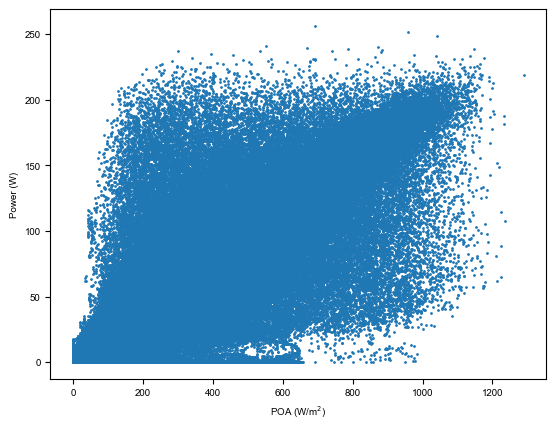

In [4]:
plt.scatter(data['poa'], data['power'], s=1)
plt.xlabel(r'POA (W/m$^2$)')
plt.ylabel('Power (W)')
plt.show()

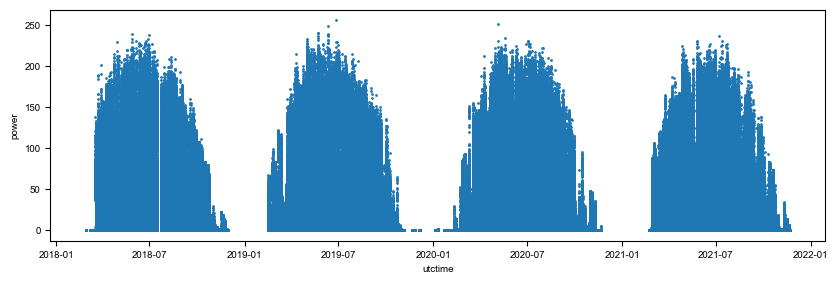

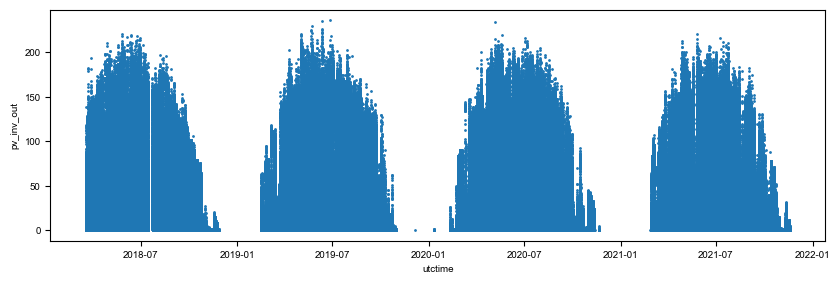

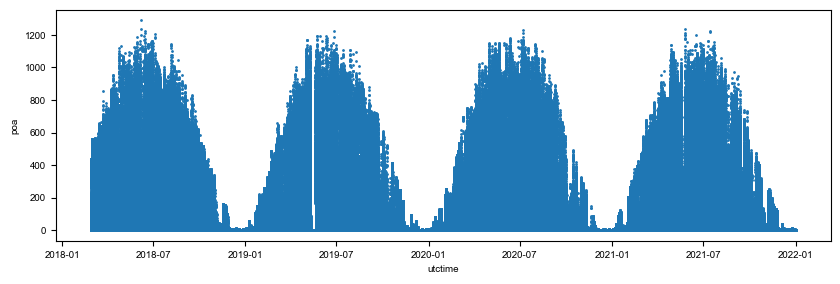

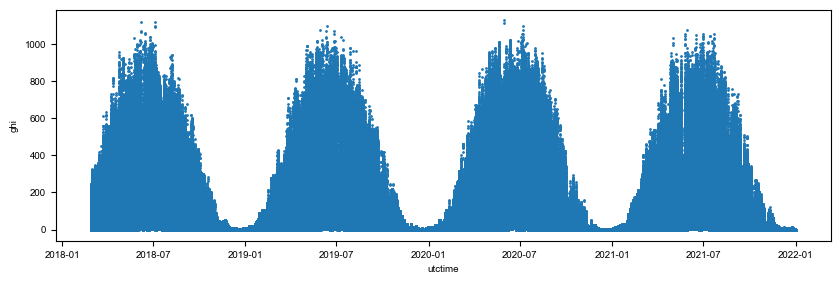

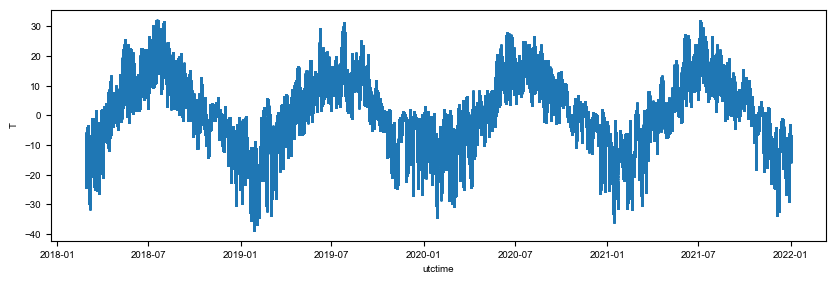

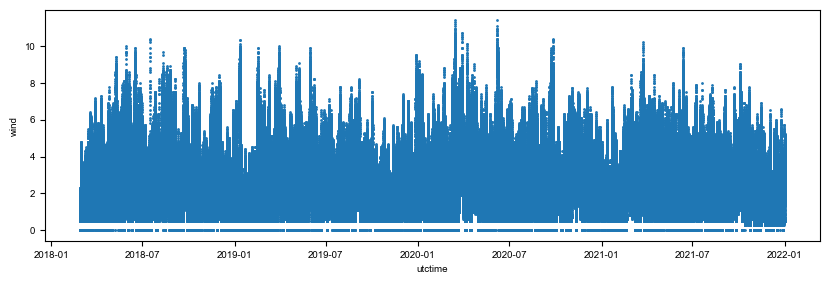

In [ ]:
data.plot(x='utctime', y='power', kind='scatter', s=1, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='pv_inv_out', kind='scatter', s=1, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='poa', kind='scatter', s=1, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='ghi', kind='scatter', s=1, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='T', kind='scatter', s=1, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='wind', kind='scatter', s=1, figsize=(10,3))
plt.show()

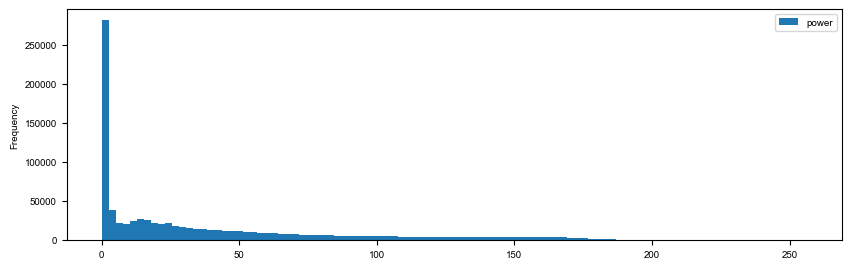

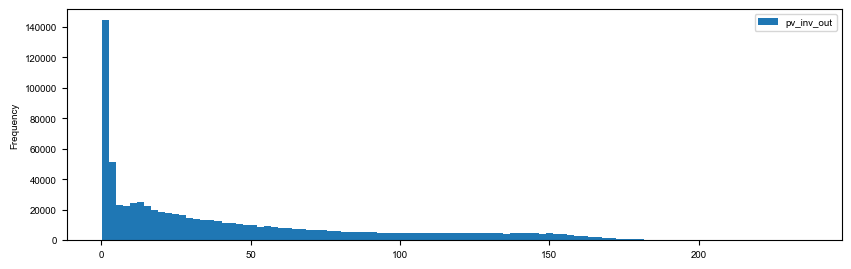

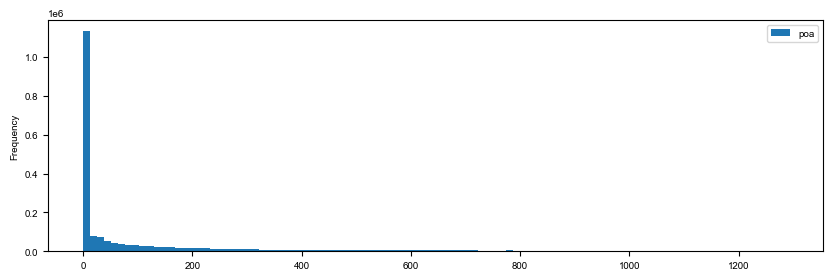

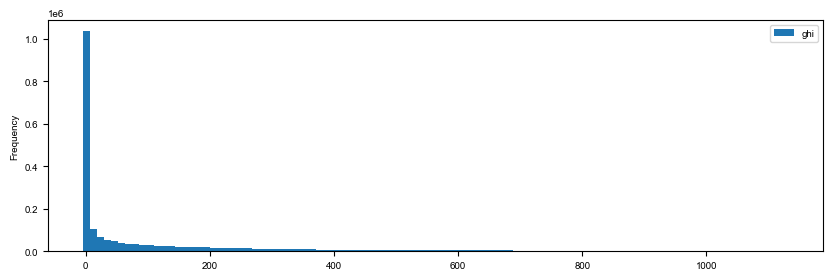

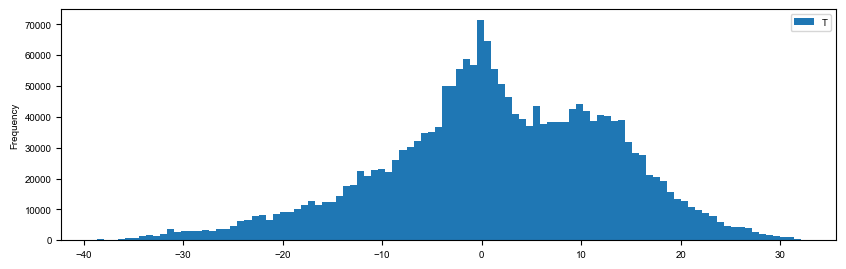

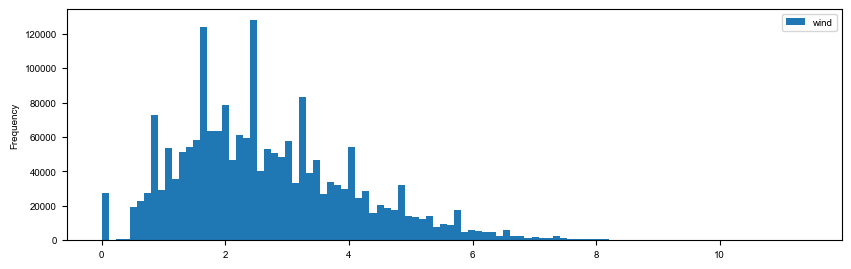

In [17]:
data.plot(x='utctime', y='power', kind='hist', bins=100, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='pv_inv_out', kind='hist', bins=100, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='poa', kind='hist', bins=100, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='ghi', kind='hist', bins=100, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='T', kind='hist', bins=100, figsize=(10,3))
plt.show()

data.plot(x='utctime', y='wind', kind='hist', bins=100, figsize=(10,3))
plt.show()

## Initial filtering

First, let's apply nighttime filter, IEC threhold filters, and quality control (QC) filter by Karhu et al.

In [5]:
data_day = data[filters.daytime(data)]

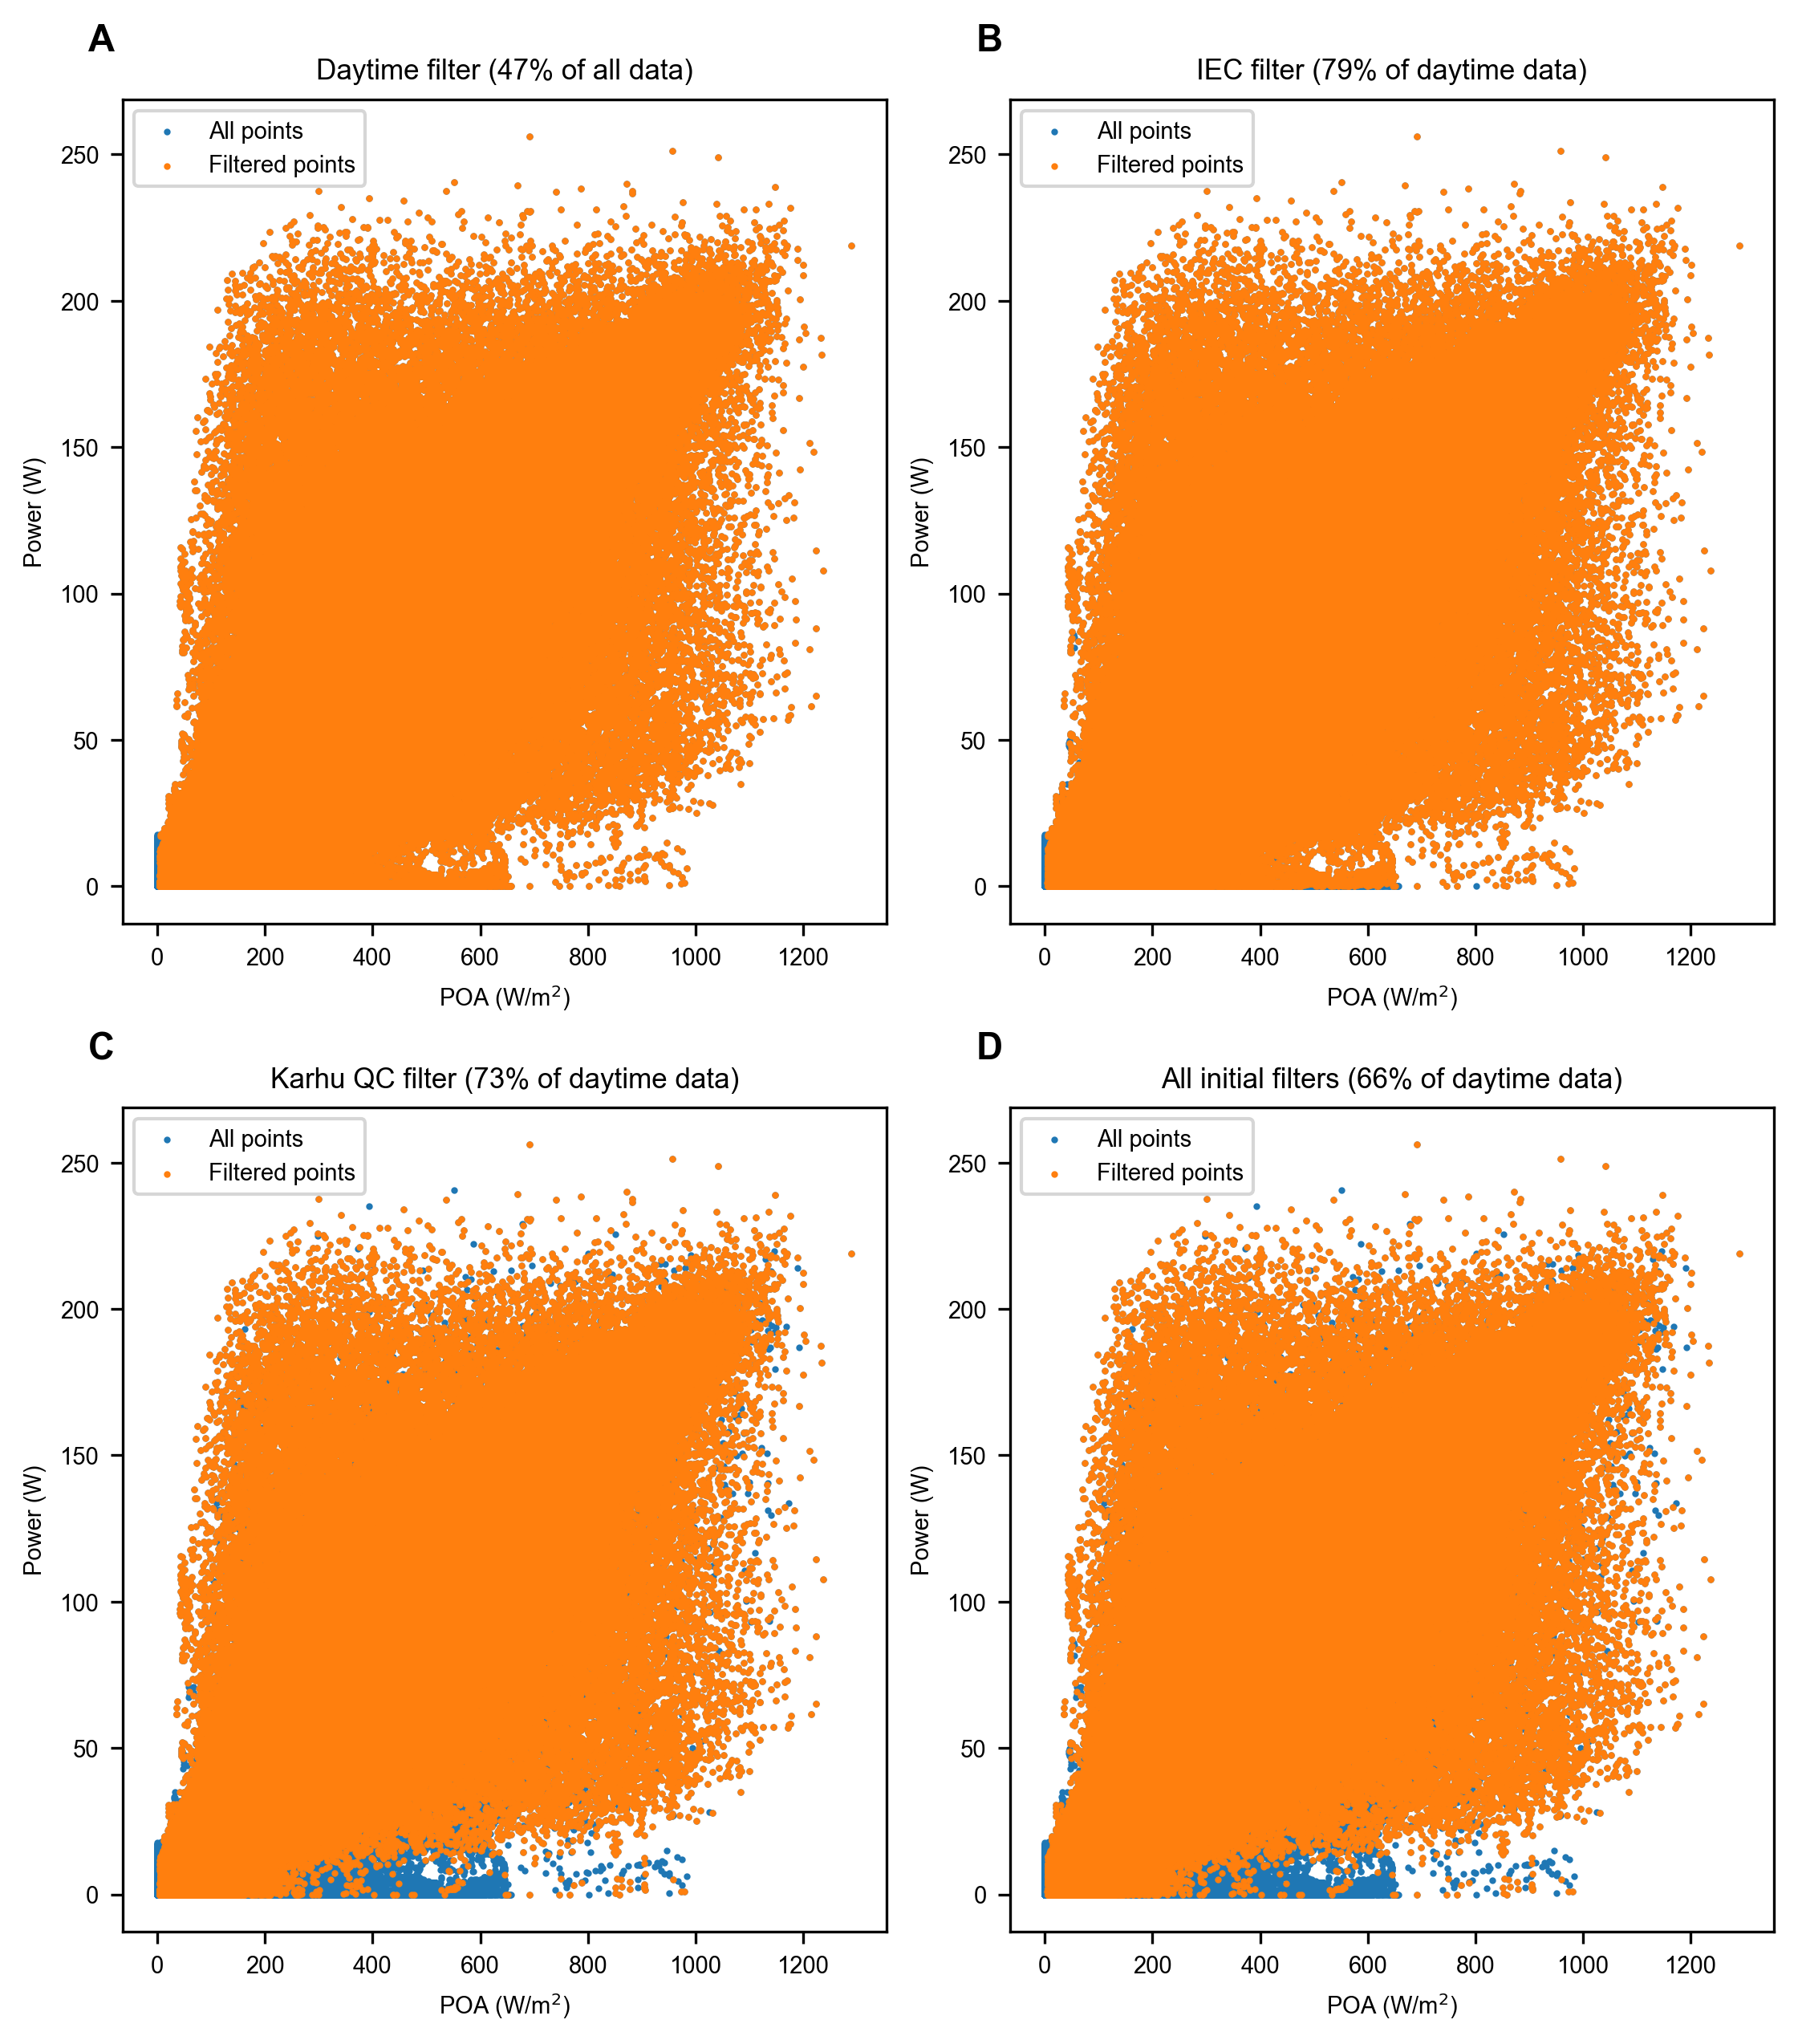

In [19]:
fig, ((ax0, ax1), (ax3, ax4)) = plt.subplots(2, 2, figsize=(2244/300,2544/300), dpi=300)

ax0.scatter(data['poa'], data['power'], s=1, label='All points')
ax0.scatter(data_day['poa'], data_day['power'], s=1, label='Filtered points')
ax0.set_xlabel(r'POA (W/m$^2$)')
ax0.set_ylabel('Power (W)')
ax0.set_title(f'Daytime filter ({(len(data_day)/len(data))*100:.0f}% of all data)')
ax0.legend(loc='upper left')

ax1.scatter(data['poa'], data['power'], s=1, label='All points')
ax1.scatter(data_day[filters.IEC(data_day, 260)]['poa'], data_day[filters.IEC(data_day, 260)]['power'], s=1, label='Filtered points')
ax1.set_xlabel(r'POA (W/m$^2$)')
ax1.set_ylabel('Power (W)')
ax1.set_title(f'IEC filter ({(len(data_day[filters.IEC(data_day, 260)])/len(data_day))*100:.0f}% of daytime data)')
ax1.legend(loc='upper left')

#ax2.scatter(data['poa'], data['power'], s=1, label='All points')
#ax2.scatter(data_day[filters.threshold(data_day, 'power', upper=20000)]['poa'], data_day[filters.threshold(data_day, 'power', upper=20000)]['power'], s=1, label='Filtered points')
#ax2.set_xlabel(r'POA (W/m$^2$)')
#ax2.set_ylabel('Power (W)')
#ax2.set_title(f'Clipping filter ({(len(data_day[filters.threshold(data_day, 'power', upper=20000)])/len(data_day))*100:.1f}% of daytime data)')
#ax2.legend(loc='upper left')

# Karhu filter
filter_mask = (data_day['dataQC'] == 1) & (data_day['snow'] == 0) & (data_day['viss_day'] == '[0, 0, 0, 0]')
ax3.scatter(data['poa'], data['power'], s=1, label='All points')
ax3.scatter(data_day[filter_mask]['poa'], data_day[filter_mask]['power'], s=1, label='Filtered points')
ax3.set_xlabel(r'POA (W/m$^2$)')
ax3.set_ylabel('Power (W)')
ax3.set_title(f'Karhu QC filter ({(len(data_day[filter_mask])/len(data_day))*100:.0f}% of daytime data)')
ax3.legend(loc='upper left')

# All filters
all_filter_mask = filters.IEC(data_day, 260) & filters.threshold(data_day, 'power', upper=20000) & filter_mask
ax4.scatter(data['poa'], data['power'], s=1, label='All points')
ax4.scatter(data_day[all_filter_mask]['poa'], data_day[all_filter_mask]['power'], s=1, label='Filtered points')
ax4.set_xlabel(r'POA (W/m$^2$)')
ax4.set_ylabel('Power (W)')
ax4.set_title(f'All initial filters ({(len(data_day[all_filter_mask])/len(data_day))*100:.0f}% of daytime data)')
ax4.legend(loc='upper left')

#ax5.remove()

for a, letter in list(zip([ax0, ax1, ax3, ax4], 
                        ['A', 'B', 'C', 'D'])):
    x0, xmax = a.set_xlim()
    y0, ymax = a.set_ylim()
    data_width = xmax - x0
    data_height = ymax - y0
    a.text(x0-(0.01*data_width), (y0 + 1.05*data_height), letter, weight='bold', fontsize=11, va='bottom', ha='right')


plt.tight_layout()
save_figure_path = os.path.join('Z:', 'Ongoing_works', 'EUPVSEC_25', 'Manuscript', 'Figures', 'sodankyla20_initial_filters.jpeg')
plt.savefig(save_figure_path, bbox_inches='tight', dpi=300)
plt.show()


## Outlier filtering
After initial filtering, there remains some outlying power-irradiance values, which should be removed for better performance analysis.

In [6]:
filter_mask = filters.daytime(data) & filters.IEC(data, 260) & filters.threshold(data, 'power', upper=20000) & \
              (data['dataQC'] == 1) & (data['snow'] == 0) & (data['viss_day'] == '[0, 0, 0, 0]')
data_filtered = data[filter_mask]

### $\pm$ 2sd around instantaneous PR
This was used e.g., in [1]

[1]  https://doi.org/10.1002/pip.3397

In [21]:

# Get mean and standard deviation of P/POA (which is basically the same as PR)
data_filtered['p/poa'] = data.power / data.poa
p_poa_mean = data_filtered['p/poa'].mean()
p_poa_sd = data_filtered['p/poa'].std()
p_poa_mask = (data_filtered['p/poa'] > p_poa_mean - 2*p_poa_sd) & (data_filtered['p/poa'] < p_poa_mean + 2*p_poa_sd)

C:\Users\plkart\AppData\Local\Temp\ipykernel_16808\1398006881.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_filtered['p/poa'] = data.power / data.poa


Share of data after filtering: 0.971


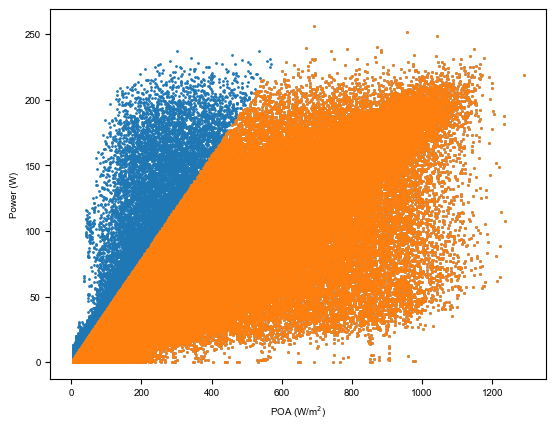

In [22]:
plt.scatter(data_filtered['poa'], data_filtered['power'], s=1, alpha=1)
plt.scatter(data_filtered[p_poa_mask]['poa'], data_filtered[p_poa_mask]['power'], s=1, alpha=1)
plt.xlabel(r'POA (W/m$^2$)')
plt.ylabel('Power (W)')

# Amount of data filtered
print('Share of data after filtering: {:.3f}'.format(len(data_filtered[p_poa_mask])/len(data_filtered)))


plt.show()

### Rolling window

Share of data after filtering compared with pre-filtered data: 0.819
Share of data after filtering compared with all daytime data: 0.544


C:\Users\plkart\AppData\Local\Temp\ipykernel_13932\2150192594.py:19: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\plkart\AppData\Local\Temp\ipykernel_13932\2150192594.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_figure_path, bbox_inches='tight', dpi=300)
C:\Users\plkart\AppData\Local\Temp\ipykernel_13932\2150192594.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_figure_path, bbox_inches='tight', dpi=300)
c:\Users\plkart\OneDrive - O365 Turun yliopisto\MatEng\codes_git2\pv-power-and-performance-modelling\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


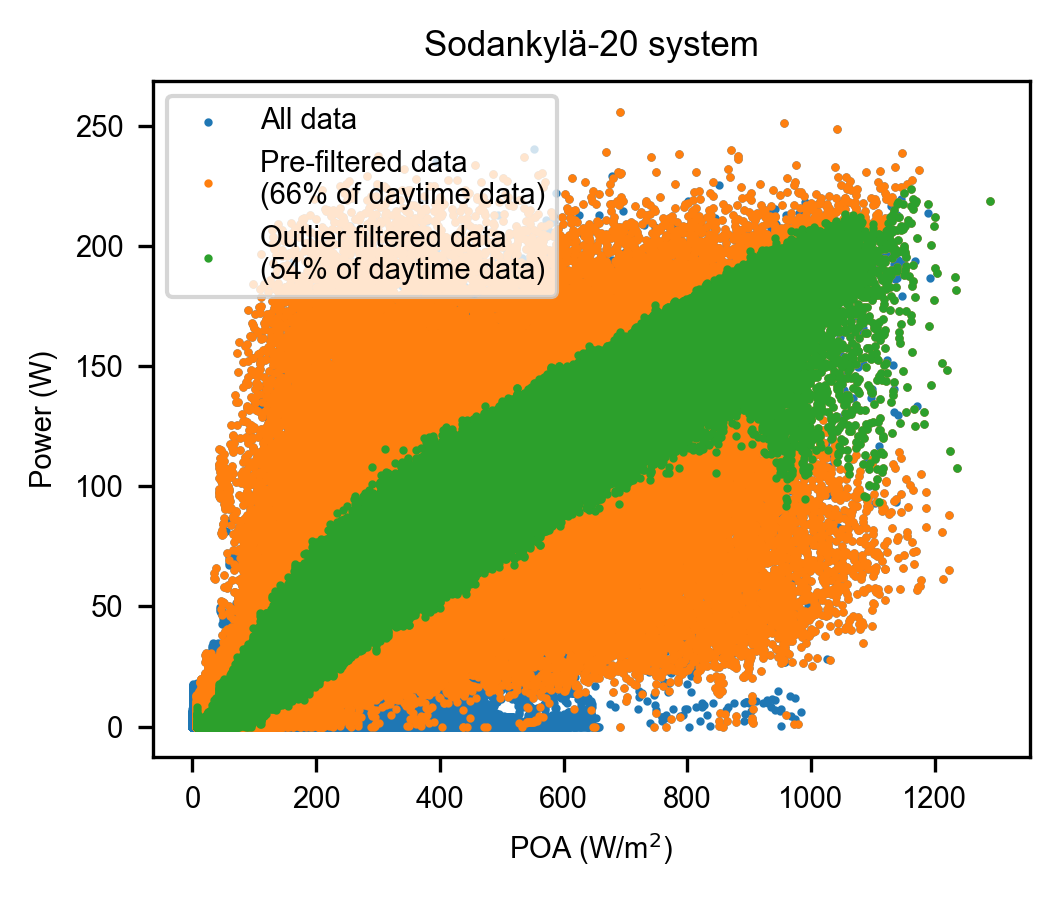

In [8]:
rolling_filter = filters.rolling_outlier_filter(data_filtered, window_size=100, window_width=1)

fig, ax = plt.subplots(1,1, figsize=(1063/300, 900/300), dpi=300)

ax.scatter(data['poa'], data['power'],  s=1, alpha=1, label='All data')
ax.scatter(data_filtered['poa'], data_filtered['power'], s=1, alpha=1, 
           label=f'Pre-filtered data\n({len(data_filtered)/len(data[filters.daytime(data)])*100:.0f}% of daytime data)')
ax.scatter(data_filtered[rolling_filter]['poa'], data_filtered[rolling_filter]['power'], s=1, alpha=1,
           label=f'Outlier filtered data\n({len(data_filtered[rolling_filter])/len(data[filters.daytime(data)])*100:.0f}% of daytime data)')
ax.set_xlabel(r'POA (W/m$^2$)')
ax.set_ylabel('Power (W)')
ax.legend()
ax.set_title('Sodankylä-20 system')

# Amount of data filtered
print('Share of data after filtering compared with pre-filtered data: {:.3f}'.format(len(data_filtered[rolling_filter])/len(data_filtered)))
print('Share of data after filtering compared with all daytime data: {:.3f}'.format(len(data_filtered[rolling_filter])/len(data[filters.daytime(data)])))

plt.tight_layout()
save_figure_path = os.path.join('Z:', 'Ongoing_works', 'EUPVSEC_25', 'Manuscript', 'Figures', 'sodankyla20_outlier_filter.jpeg')
plt.savefig(save_figure_path, bbox_inches='tight', dpi=300)

plt.show()

## Clear-sky filtering

In [7]:
filter_mask = filters.daytime(data) & filters.IEC(data, 260) & filters.threshold(data, 'power', upper=20000) & \
              (data['dataQC'] == 1) & (data['snow'] == 0) & (data['viss_day'] == '[0, 0, 0, 0]')
data_filtered = data[filter_mask]

Share of data after filtering compared with pre-filtered data: 0.359
Share of data after filtering compared with all daytime data: 0.238


C:\Users\plkart\AppData\Local\Temp\ipykernel_13932\1196675364.py:19: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
C:\Users\plkart\AppData\Local\Temp\ipykernel_13932\1196675364.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_figure_path, bbox_inches='tight', dpi=300)
C:\Users\plkart\AppData\Local\Temp\ipykernel_13932\1196675364.py:21: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig(save_figure_path, bbox_inches='tight', dpi=300)
c:\Users\plkart\OneDrive - O365 Turun yliopisto\MatEng\codes_git2\pv-power-and-performance-modelling\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


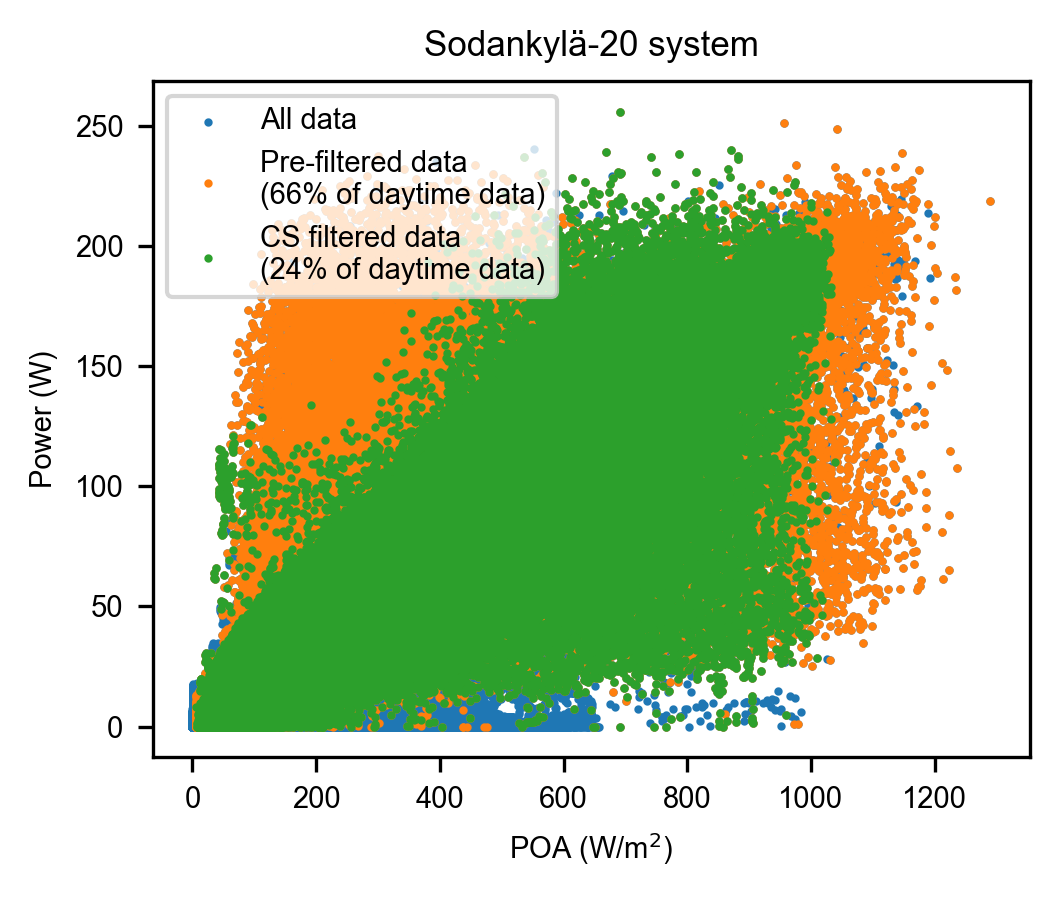

In [9]:
cs_filter = filters.clear_sky(data_filtered, latitude=config.latitude_sodankyla, longitude=config.longitude_sodankyla, 
                              altitude=config.elevation_sodankyla)

fig, ax = plt.subplots(1,1, figsize=(1063/300, 900/300), dpi=300)

ax.scatter(data['poa'], data['power'],  s=1, alpha=1, label='All data')
ax.scatter(data_filtered['poa'], data_filtered['power'], s=1, alpha=1, 
           label=f'Pre-filtered data\n({len(data_filtered)/len(data[filters.daytime(data)])*100:.0f}% of daytime data)')
ax.scatter(data_filtered[cs_filter]['poa'], data_filtered[cs_filter]['power'], s=1, alpha=1,
           label=f'CS filtered data\n({len(data_filtered[cs_filter])/len(data[filters.daytime(data)])*100:.0f}% of daytime data)')
ax.set_xlabel(r'POA (W/m$^2$)')
ax.set_ylabel('Power (W)')
ax.legend()
ax.set_title('Sodankylä-20 system')
# Amount of data filtered
print('Share of data after filtering compared with pre-filtered data: {:.3f}'.format(len(data_filtered[cs_filter])/len(data_filtered)))
print('Share of data after filtering compared with all daytime data: {:.3f}'.format(len(data_filtered[cs_filter])/len(data[filters.daytime(data)])))

plt.tight_layout()
save_figure_path = os.path.join('Z:', 'Ongoing_works', 'EUPVSEC_25', 'Manuscript', 'Figures', 'sodankyla20_clearsky_filter.jpeg')
plt.savefig(save_figure_path, bbox_inches='tight', dpi=300)

plt.show()